# Luin of Celtchar final (hopefully) Nozzle representation
## For Pe = 1.1, using CEA run #2 from 07_film_cooling
## Allows for 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Part 1: Nozzle Contour

In [2]:
# See 07_film_cooling.ipynb, we're going for just under the perfectly efficient burn.
# Something about how CEA deals with soot makes the film cooling case have much lower c*
throat_diameter = 0.0305 # m
throat_radius = throat_diameter / 2

In [3]:
location = 'data/nozzle_input/'
#location =  "/home/daniel/repos/Three-Dimensional-Nozzle-Design-Code/bazel-bin/src/main.runfiles/_main/"

In [4]:
df = pd.read_csv(f"{location}/wall.out", delim_whitespace=True, index_col=0)

/tmp/ipykernel_3798/2987922737.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f"{location}/wall.out", delim_whitespace=True, index_col=0)


In [5]:
df.columns

Index(['j', 'X/R*', 'R/R*', 'mach', 'theta(deg)', 'Pressure,', 'psia'], dtype='object')

In [6]:
df.head()

,j,X/R*,R/R*,mach,theta(deg),"Pressure,",psia
i,,,,,,,
0,0,0.000000,1.0,1.13196,0.000000,136.959,NaN
0,1,0.000100,1.0,1.13216,0.007174,136.925,NaN
0,2,0.000401,1.0,1.13276,0.028705,136.824,NaN
0,3,0.000902,1.0,1.13378,0.064624,136.654,NaN
0,4,0.001605,1.0,1.13520,0.114983,136.416,NaN


In [7]:
df["x"] = df["X/R*"] * throat_radius * 1e3
df["r"] = df["R/R*"] * throat_radius * 1e3

In [8]:
dpi = plt.gcf().get_dpi()
mm_per_inch = 25.4
pixels_per_mm = dpi / mm_per_inch

<Figure size 640x480 with 0 Axes>

In [22]:
df.tail()

,X/R,Y/R,Z/R,R/R,Mach,Pres,Temp,Rho,Theta,Gamma,Massflow,J,r,x,pressure_bar
34976,2.97247,-4.351010e-16,1.77643,1.77643,2.35861,20.8044,2622.07,0.000498,10.79850,1.27,5.97414,93.0,27.090557,45.330167,1.434413
34977,3.17310,-4.441670e-16,1.81345,1.81345,2.39177,19.6560,2590.60,0.000476,10.10140,1.27,5.97650,96.0,27.655112,48.389775,1.355234
34978,3.51532,-4.582370e-16,1.87090,1.87090,2.44448,17.9559,2541.26,0.000443,8.96396,1.27,5.96867,99.0,28.531225,53.608630,1.238016
34979,3.93828,-4.733570e-16,1.93263,1.93263,2.50328,16.2285,2487.19,0.000409,7.65717,1.27,5.95429,102.0,29.472608,60.058770,1.118916
34980,4.12219,-4.791940e-16,1.95646,1.95646,2.52708,15.5764,2465.60,0.000396,7.11579,1.27,5.95350,104.0,29.836015,62.863397,1.073955


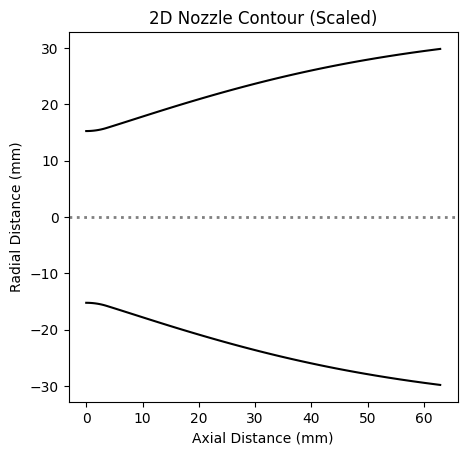

In [9]:
df["-r"] = -df["r"]
ax = df[["x", "r", "-r"]].plot(x='x')
for line in ax.get_lines():
    line.set_color('black')
ax.set_title('2D Nozzle Contour (Scaled)')
ax.set_xlabel('Axial Distance (mm)')
ax.set_ylabel('Radial Distance (mm)')
ax.axhline(0, color='grey', linestyle=':', linewidth=2)
ax.legend().remove()
ax.set_aspect('equal')

In [10]:
PSI_TO_BAR = 0.0689476

In [11]:
df["pressure_bar"] = df["Pressure,"] * PSI_TO_BAR

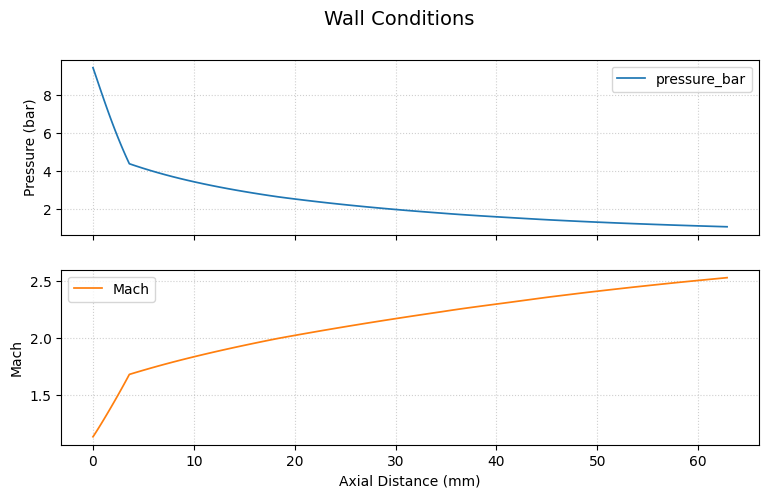

In [12]:
# optionally rename columns for nicer labels in the plots
rename_map = {'pressure_bar': 'pressure_bar', 'mach': 'Mach'}
plot_df = df.rename(columns=rename_map)

cols = ['x', 'pressure_bar', 'Mach']

axs = plot_df[cols].plot(x='x', subplots=True, figsize=(9, 5), linewidth=1.25)

axs[0].set_ylabel('Pressure (bar)')
axs[1].set_ylabel('Mach')
axs[-1].set_xlabel('Axial Distance (mm)')

for ax in axs:
    ax.grid(True, linestyle=':', alpha=0.6)
    #ax.legend().remove()  # remove per-subplot legends (optional)

fig = axs[0].get_figure()
fig.suptitle('Wall Conditions', fontsize=14)
fig.subplots_adjust(top=0.88)

In [13]:
solidworks = df.copy()
solidworks["z"] = 0.0
solidworks.rename(columns={"x": "x", "r": "y"}, inplace=True)

In [14]:
solidworks.to_csv('data/nozzle_output/solidworks_nozzle.csv', index=False, columns=["x", "y", "z"], float_format='%.6f', header=False)

## Part 2: Internal Nozzle conditions

In [15]:
filename = f"{location}/MOC_SL.plt"

In [16]:
with open(filename, 'r') as f:
    columns = []
    for line in f:
        if line.startswith('VARIABLES'):
            columns = [x.strip().strip('"') for x in line.split('=')[1].split(',')]
            break

columns = [col for col in columns if col]

In [17]:
data = []
with open(filename) as f:
    for line in f:
        if any(line.startswith(x) for x in ['VARIABLES', 'TITLE', 'text', 'zone']):
            continue
        try:
            vals = [float(x) for x in line.split()]
            data.append(vals)
        except:
            continue

In [18]:
data = np.array(data)
df = pd.DataFrame(data, columns=columns)

In [19]:
df["r"] = df["R/R"] * throat_radius * 1e3
df["x"] = df["X/R"] * throat_radius * 1e3
df["pressure_bar"] = df["Pres"] * PSI_TO_BAR

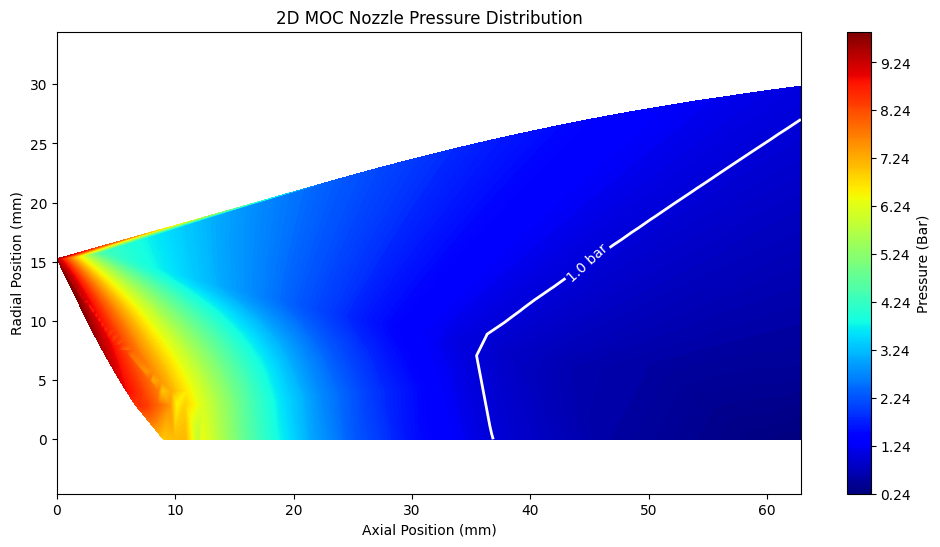

In [20]:
plt.figure(figsize=(12,6))
plt.tricontourf(df['x'], df['r'], df['pressure_bar'], levels=300, cmap='jet')
plt.colorbar(label='Pressure (Bar)')

# Highlight 1 bar contour
contour_1bar = plt.tricontour(df['x'], df['r'], df['pressure_bar'], 
                               levels=[1.0], colors='white', linewidths=2)
plt.clabel(contour_1bar, inline=True, fontsize=10, fmt='1.0 bar')

plt.title('2D MOC Nozzle Pressure Distribution')
plt.xlabel('Axial Position (mm)')
plt.ylabel('Radial Position (mm)')
plt.axis('equal')
plt.show()

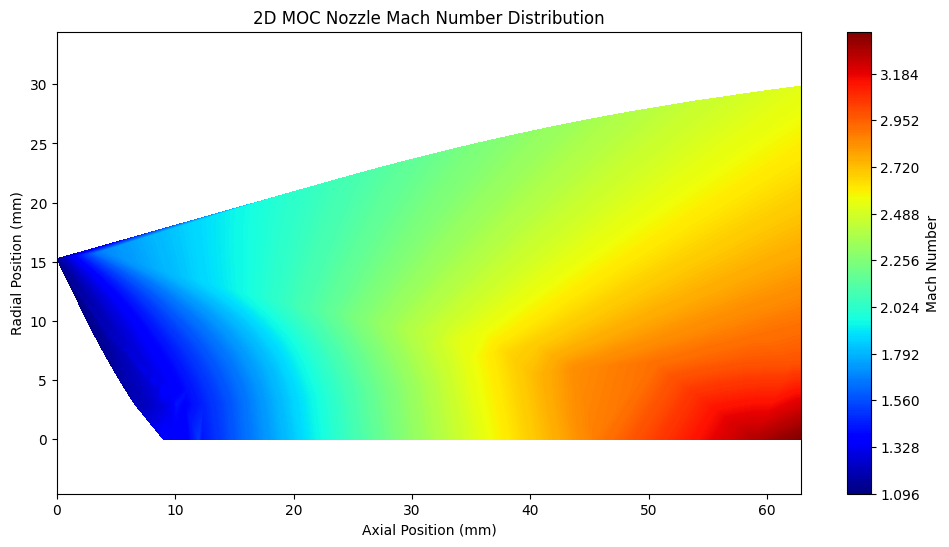

In [21]:
plt.figure(figsize=(12,6))
plt.tricontourf(df['x'], df['r'], df['Mach'], levels=300, cmap='jet')
plt.colorbar(label='Mach Number')

plt.title('2D MOC Nozzle Mach Number Distribution')
plt.xlabel('Axial Position (mm)')
plt.ylabel('Radial Position (mm)')
plt.axis('equal')
plt.show()